In [1]:
import os
import sys

# Change the notebook's active working directory to the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Ensure the root path is also in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from pmdarima import auto_arima

from src.forecasting.data import ForecastDataLoader

In [3]:
## load the data
df = ForecastDataLoader.load_daily_sales()

df.head()

c:\end-to-end-Data-Science-project\AI-demand-intelligence-platform\src\forecasting\data.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,date,sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0


In [5]:
## prepare the series
model = auto_arima(

    df['sales'],

    seasonal=True,

    m=7,

    start_p=0,
    start_q=0,

    max_p=5,
    max_q=5,

    start_P=0,
    start_Q=0,

    max_P=2,
    max_Q=2,

    d=None,
    D=None,

    trace=True,

    error_action="ignore",

    suppress_warnings=True,

    stepwise=True,
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=38649.513, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=37412.200, Time=0.70 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=37890.868, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=38647.518, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=38644.729, Time=0.05 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=37140.674, Time=1.28 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=37064.247, Time=2.52 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=37304.734, Time=1.46 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=4.75 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=37375.348, Time=2.61 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=2.64 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=3.45 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=2.55 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=inf, Time=2.96 sec
 ARIMA(2,1,1)(2,0,1)[7] intercept   : AIC=inf, Ti

In [6]:
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1913
Model:             SARIMAX(1, 1, 0)x(2, 0, [1], 7)   Log Likelihood              -18526.123
Date:                             Sat, 04 Jul 2026   AIC                          37064.247
Time:                                     15:09:56   BIC                          37097.582
Sample:                                          0   HQIC                         37076.515
                                            - 1913                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   -486.1339     55.244     -8.800      0.000    -594.410    -377.858
ar.L1         -0.3560      

In [7]:
## extract the orders
print("ARIMA Order:", model.order)

print("Seasonal Order:", model.seasonal_order)

ARIMA Order: (1, 1, 0)
Seasonal Order: (2, 0, 1, 7)


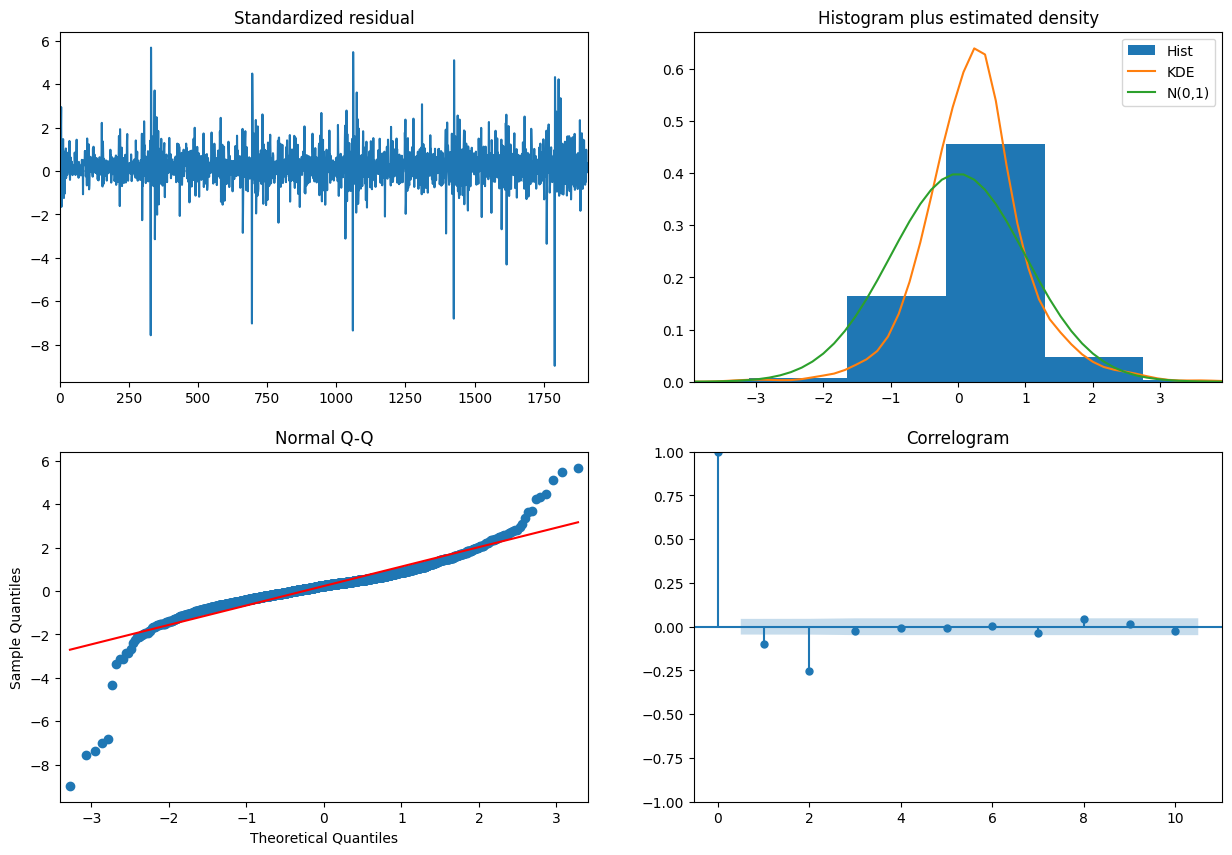

In [8]:
## diagnostic plots
model.plot_diagnostics(
    figsize=(15,10)
)

plt.show()

In [9]:
## save the summary
with open(
    "artifacts/auto_arima_summary.txt",
    "w"
) as f:

    f.write(model.summary().as_text())